In [1]:
from pathlib import Path
import numpy as np

dataset_path = Path("datasets/base_params_300_periods")

str_jpc_config = (dataset_path / "jpc_config.txt").read_text()
str_quantum_parameters = (dataset_path / "quantum_parameters.txt").read_text()
str_encoding = (dataset_path / "encoding.txt").read_text()

print(str_jpc_config)
print(str_quantum_parameters)
print(str_encoding)

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)

QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)

Encoding(
    encoding_parameters=('g_sq',),
    encoding_function=Linear()
)



In [2]:
X = np.load(dataset_path / "X.npy")
Y = np.load(dataset_path / "Y.npy")

X.shape, Y.shape

((30, 80), (30, 80, 1))

In [3]:
F_quad = np.load(dataset_path / "f_quad.npy")
F_quad_poly = np.load(dataset_path / "f_quad_poly.npy")
F_probas = np.load(dataset_path / "f_probas.npy")

F_quad.shape, F_quad_poly.shape, F_probas.shape

((30, 80, 40), (30, 80, 140), (30, 80, 40))

In [4]:
nb_batches_train = 25

X_train, X_test = X[:nb_batches_train], X[nb_batches_train:]
Y_train, Y_test = Y[:nb_batches_train].reshape(-1, 1), Y[nb_batches_train:].reshape(-1, 1)

F_train_quad, F_test_quad = F_quad[:nb_batches_train].reshape(-1, F_quad.shape[-1]), F_quad[nb_batches_train:].reshape(-1, F_quad.shape[-1])
F_train_quad_poly, F_test_quad_poly = F_quad_poly[:nb_batches_train].reshape(-1, F_quad_poly.shape[-1]), F_quad_poly[nb_batches_train:].reshape(-1, F_quad_poly.shape[-1])
F_train_probas, F_test_probas = F_probas[:nb_batches_train].reshape(-1, F_probas.shape[-1]), F_probas[nb_batches_train:].reshape(-1, F_probas.shape[-1])

F_train_quad.shape, F_train_quad_poly.shape, F_train_probas.shape

((2000, 40), (2000, 140), (2000, 40))

In [5]:
from quantum_learn import Reservoir

QRC_quadratures = Reservoir()
QRC_quadratures_poly = Reservoir()
QRC_probas = Reservoir()

QRC_quadratures.fit(F=F_train_quad, Y=Y_train)
QRC_quadratures_poly.fit(F=F_train_quad_poly, Y=Y_train)
QRC_probas.fit(F=F_train_probas, Y=Y_train)


In [6]:
Y_pred_quad = QRC_quadratures(F_test_quad)
Y_pred_quad_poly = QRC_quadratures_poly(F_test_quad_poly)
Y_pred_probas = QRC_probas(F_test_probas)


In [7]:
threshold = 0.5

Y_pred_01_quad = Y_pred_quad >= threshold
acc_quad = np.mean(Y_pred_01_quad == Y_test)
print(f"Accuracy quadratures = {acc_quad * 1e2} %")

Y_pred_01_quad_poly = Y_pred_quad_poly >= threshold
acc_quad_poly = np.mean(Y_pred_01_quad_poly == Y_test)
print(f"Accuracy quadratures poly= {acc_quad_poly * 1e2} %")

Y_pred_01_probas = Y_pred_probas >= threshold
acc_probas = np.mean(Y_pred_01_probas == Y_test)
print(f"Accuracy probas = {acc_probas * 1e2} %")


Accuracy quadratures = 87.5 %
Accuracy quadratures poly= 100.0 %
Accuracy probas = 100.0 %


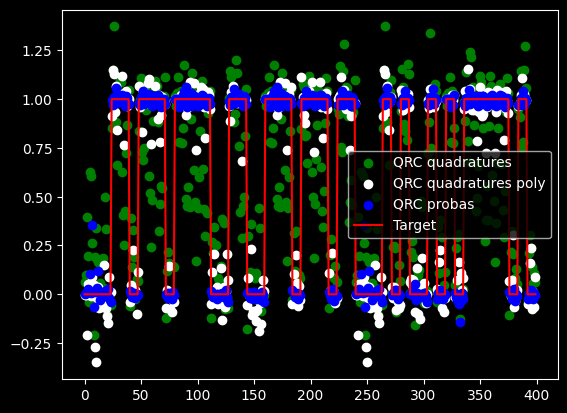

In [8]:
import matplotlib.pyplot as plt

X = range(len(Y_pred_quad))
plt.scatter(X, Y_pred_quad, label="QRC quadratures", color="g")
plt.scatter(X, Y_pred_quad_poly, label="QRC quadratures poly", color="w")
plt.scatter(X, Y_pred_probas, label="QRC probas", color="b")
plt.plot(X, Y_test, label="Target", color="r")
plt.legend()
plt.show()
